# Assembly of one-dimensional linear finite elements

We solve

$$
-u''=1\quad\text{in }(0,1),
\qquad u(0)=0,
\qquad u'(1)=0,
$$

whose exact solution is $u(x)=x-x^2/2$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=5, suppress=True)


def exact_solution(x):
    return x - 0.5 * x**2

## Plotting helpers

Run the collapsed cell once. Its contents are not part of the finite element algorithm.

In [2]:
def plot_one_mesh(nodes, U, x, u_exact, error, l2, sup):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
    ax[0].plot(x, u_exact, "k--", linewidth=2, label="exact")
    ax[0].plot(nodes, U, "o-", label="finite element")
    ax[0].set(xlabel=r"$x$", ylabel=r"$u(x)$", title="Finite element and exact solutions")
    ax[0].legend()
    ax[0].grid(alpha=0.25)
    ax[1].plot(x, np.abs(error), color="tab:red")
    ax[1].set(xlabel=r"$x$", ylabel=r"$|u-u_h|$", title=rf"$\|e\|_{{L^2}}={l2:.3e}$, $\|e\|_\infty={sup:.3e}$")
    ax[1].grid(alpha=0.25)
    fig.tight_layout()
    plt.show()


def plot_convergence(solutions, h, errors, rates):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
    x = np.linspace(0.0, 1.0, 1001)
    ax[0].plot(x, exact_solution(x), "k--", linewidth=2, label="exact")
    for N, nodes, U in solutions:
        ax[0].plot(nodes, U, "o-", markersize=3, label=rf"$N={N}$")
    ax[0].set(xlabel=r"$x$", ylabel=r"$u(x)$", title="Solutions on refined meshes")
    ax[0].legend(ncol=2, fontsize=8)
    ax[0].grid(alpha=0.25)
    order = np.argsort(h)
    names = (r"$L^2$", r"$L^\infty$", "energy", r"$H^1$")
    marks = ("o-", "s-", "^-", "d-")
    for name, mark, values, rate in zip(names, marks, errors, rates):
        ax[1].loglog(h[order], values[order], mark, label=rf"{name}, slope $={rate:.2f}$")
    ax[1].set_xticks(h[order], labels=[f"{value:.4g}" for value in h[order]])
    ax[1].minorticks_off()
    ax[1].set(xlabel=r"element size $h$", ylabel="error norm", title="Error convergence")
    ax[1].legend(ncol=2, fontsize=8)
    ax[1].grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

## Assemble and solve

For each element, the nested loops place $F_a^e$ and $K_{ab}^e$ in the global entries identified by the connectivity array.

In [3]:
def solve_bar(N):
    nodes = np.linspace(0.0, 1.0, N + 1)
    K = np.zeros((N + 1, N + 1))
    F = np.zeros(N + 1)

    for e in range(N):
        dofs = np.array([e, e + 1])
        h_e = nodes[e + 1] - nodes[e]
        K_e = np.array([[1.0, -1.0], [-1.0, 1.0]]) / h_e
        F_e = 0.5 * h_e * np.array([1.0, 1.0])

        for a in range(2):
            F[dofs[a]] += F_e[a]
            for b in range(2):
                K[dofs[a], dofs[b]] += K_e[a, b]

    U = np.zeros(N + 1)
    U[1:] = np.linalg.solve(K[1:, 1:], F[1:])
    reaction = (K @ U - F)[0]
    return nodes, U, K, F, reaction

In [4]:
nodes, U, K, F, reaction = solve_bar(4)

print("Nodal solution U =", U)
print("Reaction at x=0 =", reaction)

Nodal solution U = [0.      0.21875 0.375   0.46875 0.5    ]
Reaction at x=0 = -0.9999999999999997


## Begin with the displacement error

Let $e=u-u_h$. We first compute $\lVert e\rVert_{L^2}$ and $\lVert e\rVert_\infty$, which measure errors in the solution values.

In [5]:
def displacement_errors(nodes, U):
    x = np.linspace(0.0, 1.0, 200 * (len(nodes) - 1) + 1)
    u_exact = exact_solution(x)
    error = u_exact - np.interp(x, nodes, U)
    l2 = np.sqrt(np.trapezoid(error**2, x))
    sup = np.max(np.abs(error))
    return x, u_exact, error, l2, sup

L2 error = 5.705443e-03
Supremum error = 7.812500e-03


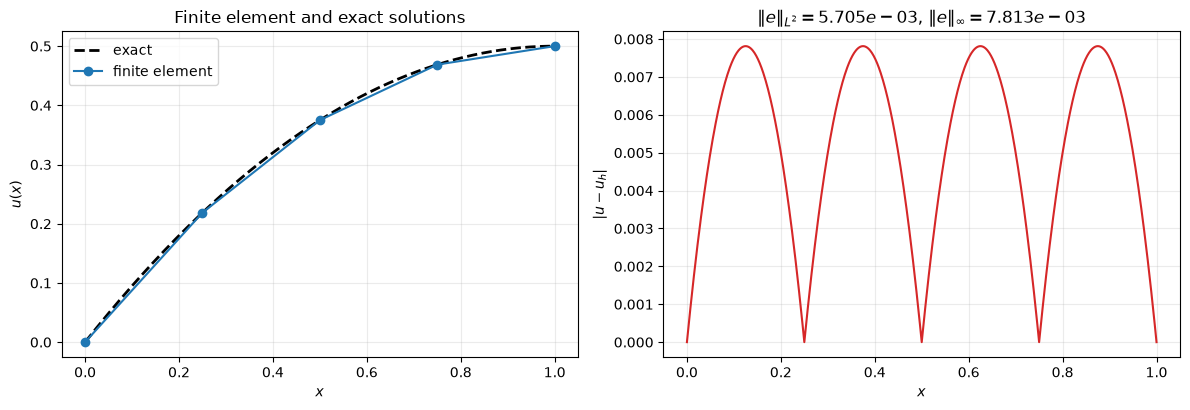

In [6]:
x, u_exact, error, l2_error, sup_error = displacement_errors(nodes, U)
print(f"L2 error = {l2_error:.6e}")
print(f"Supremum error = {sup_error:.6e}")
plot_one_mesh(nodes, U, x, u_exact, error, l2_error, sup_error)

The finite element and exact solutions agree at the nodes for this problem. Between nodes, $u_h$ is linear and $u$ is quadratic, so the error is nonzero.

The preceding norms do not measure the derivative error.

## Energy and $H^1$ errors

Since $AE=1$,

$$
\lVert e\rVert_E=\left(\int_0^1(e')^2\,\mathrm{d}x\right)^{1/2},
\qquad
\lVert e\rVert_{H^1}=\left(\lVert e\rVert_{L^2}^2+\lVert e\rVert_E^2\right)^{1/2}.
$$

In [7]:
def energy_error(nodes, U):
    error_squared = 0.0
    for e in range(len(nodes) - 1):
        x = np.linspace(nodes[e], nodes[e + 1], 201)
        du_h = (U[e + 1] - U[e]) / (nodes[e + 1] - nodes[e])
        error_squared += np.trapezoid(((1.0 - x) - du_h)**2, x)
    return np.sqrt(error_squared)

In [8]:
energy = energy_error(nodes, U)
h1_error = np.sqrt(l2_error**2 + energy**2)

print(f"Energy error = {energy:.6e}")
print(f"H1 error = {h1_error:.6e}")

Energy error = 7.217059e-02
H1 error = 7.239576e-02


## Mesh refinement

The same assembly, solution, and error functions can now be reused without duplicating the algorithm.

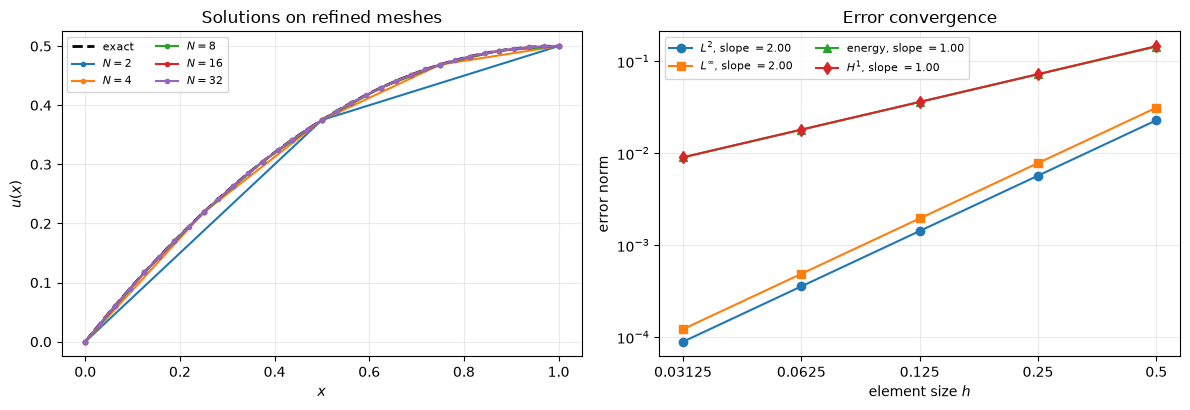

Observed rates: [2.    2.    1.    1.004]


In [9]:
mesh_sizes = np.array([2, 4, 8, 16, 32])
solutions = []
h = []
l2 = []
sup = []
energy = []
h1 = []

for N in mesh_sizes:
    nodes_N, U_N, _, _, _ = solve_bar(N)
    _, _, _, l2_N, sup_N = displacement_errors(nodes_N, U_N)
    energy_N = energy_error(nodes_N, U_N)

    solutions.append((N, nodes_N, U_N))
    h.append(1.0 / N)
    l2.append(l2_N)
    sup.append(sup_N)
    energy.append(energy_N)
    h1.append(np.sqrt(l2_N**2 + energy_N**2))

h = np.array(h)
l2 = np.array(l2)
sup = np.array(sup)
energy = np.array(energy)
h1 = np.array(h1)
errors = (l2, sup, energy, h1)
rates = []
for values in errors:
    rate = np.polyfit(np.log(h), np.log(values), 1)[0]
    rates.append(rate)

plot_convergence(solutions, h, errors, rates)
print("Observed rates:", np.round(rates, 4))

The $L^2$ and supremum errors converge at approximately second order. The energy and $H^1$ errors converge at approximately first order.